In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import uproot
import awkward as ak

In [3]:
def direction_theta_phi(dx, dy, dz, degrees=True):
    rho = np.hypot(dx, dy)
    r = np.hypot(rho, dz)

    theta = ak.where(r > 0, np.arctan2(rho, -dz), np.nan)
    # phi   = (np.arctan2(dy, dx) + np.pi) % (2*np.pi) # arrival direction 기준으로 phi=0이 +x축, phi=90도가 +y축, phi=180도가 -x축, phi=270도가 -y축이 되도록 조정
    phi   = np.arctan2(dy, dx) # 원래는 위에가 맞는데 yemi-contour를 xyz->theta-phi로 변환할때 phi가 180도씩 shift되어서 일단 이렇게 그림. 추후 수정되어야함.
    phi   = (phi + 2*np.pi) % (2*np.pi)

    if degrees:
        theta = np.degrees(theta)
        phi = np.degrees(phi)

    return r, theta, phi

In [4]:
ngen = 1000*10000
square_area = 1000*1000 # cm^2
mu_flux = 1.18*1e-7 # muons/cm^2/s
mu_flux_err = 0.03*1e-7 # muons/cm^2/s
mu_flux_plus = mu_flux + mu_flux_err
mu_flux_minus = mu_flux - mu_flux_err

mu_flux_at_area = mu_flux * square_area
mu_flux_err_at_area = mu_flux_err * square_area
simtime = ngen/mu_flux/square_area/3600/24/365 #year
simtime_plus = ngen/mu_flux_minus/square_area/3600/24/365 # year
simtime_minus = ngen/mu_flux_plus/square_area/3600/24/365 # year

print(f"Muon flux: {mu_flux} ± {mu_flux_err} muons/cm^2/s")
print(f'Generated muon area (square): {square_area} cm^2')
print(f'Simulation time: {simtime} ({simtime_plus} ~ {simtime_minus}) years')
print(f'Simulation time: {simtime*365/7} weeks')

Muon flux: 1.1799999999999998e-07 ± 2.9999999999999996e-09 muons/cm^2/s
Generated muon area (square): 1000000 cm^2
Simulation time: 2.6872705070986944 (2.7573732159795297 ~ 2.620643965600379) years
Simulation time: 140.1219621558605 weeks


In [14]:
datapath = '/proj/internal_group/cup_mc/users/jeewon/AMoRE/Stage1/02_muon/01_data/g4v10/abs_length_500cm'
file = uproot.open(datapath + "/repro_muon_1000run.root")
tree = file["prod"]
print(tree.keys())
v0x, v0y, v0z = tree['vertex.x0'].array(library='ak'), tree['vertex.y0'].array(library='ak'), tree['vertex.z0'].array(library='ak')
vname = tree['vertex.pname'].array(library='ak')
cavern_vx, cavern_vy, cavern_vz = tree['cavern.x'].array(library='ak'), tree['cavern.y'].array(library='ak'), tree['cavern.z'].array(library='ak')
cavern_pname = tree['cavern.pname'].array(library='ak')
vx, vy, vz = np.array([x[0] if len(x) > 0 else np.nan for x in cavern_vx]), np.array([y[0] if len(y) > 0 else np.nan for y in cavern_vy]), np.array([z[0] if len(z) > 0 else np.nan for z in cavern_vz])
pname = np.array([x[0] if len(x) > 0 else np.nan for x in cavern_pname])

dx, dy, dz = vx - v0x, vy - v0y, vz - v0z
r, theta, phi = direction_theta_phi(dx, dy, dz, degrees=True)

geant4_file = uproot.open('./ps_coincidence/angle_ps_coincidence_1000run.root')
# geant4_file = uproot.open('./ps_coincidence_v0/angle_ps_coincidence_1000run.root')
geant4_tree = geant4_file["tree"]
print(geant4_tree.keys())
geant4_theta = geant4_tree['theta'].array(library='np')
geant4_phi = geant4_tree['phi'].array(library='np')

# trim_file = uproot.open(datapath + "/truemuon_10000run.root")
# trim_tree = trim_file["tree"]
# print(trim_tree.keys())

['evtinfo', 'veto', 'vertex.x0', 'vertex.y0', 'vertex.z0', 'vertex.pdgcode', 'vertex.ke', 'vertex.pname', 'cavern.x', 'cavern.y', 'cavern.z', 'cavern.pdgcode', 'cavern.ke', 'cavern.pname', 'ps.edep', 'ps.detid', 'ps.id', 'psveto.edep', 'psveto.id', 'pmt.id', 'pmt.npe', 'pmt.time', 'wc.id', 'wc.npe', 'lmo.id', 'lmo.edep']
['ntheta', 'theta', 'nphi', 'phi', 'nr', 'r', 'npsveto_edep', 'psveto_edep']


In [15]:
yemi_azimuthal = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_angle_spectrum_daemonflux.txt', delimiter=' ', header=None, names=['phi', 'count'])
yemi_zenith = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_zenith_spectrum_daemonflux.txt', delimiter=' ', header=None, names=['theta', 'count'])
yemi_intensity = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_intensity_daemonflux.txt', delimiter=' ', header=None, names=['theta', 'phi', 'intensity'])    
yemi_energy = pd.read_csv('/proj/home/ibs/cup_mc/jeewon/AMoRE2/stage1/mute/result/underground/u_energy_spectrum_daemonflux.txt', delimiter=' ', header=None, names=['energy', 'count'])

yemi_theta = yemi_zenith['theta'].values
yemi_theta_count = yemi_zenith['count'].values

yemi_azimuthal['phi'] = (yemi_azimuthal['phi'] + 180) % 360
yemi_azimuthal = yemi_azimuthal.sort_values(by='phi').reset_index(drop=True)
yemi_phi = yemi_azimuthal['phi'].values
yemi_phi_count = yemi_azimuthal['count'].values

yemi_intensity['phi'] = (yemi_intensity['phi'] + 180) % 360
yemi_intensity = yemi_intensity.sort_values(by=['theta', 'phi']).reset_index(drop=True)

yemi_ke = yemi_energy['energy'].values
yemi_ke_count = yemi_energy['count'].values

In [16]:
gen_file = uproot.open(datapath + "/generated_muon_1000run.root")
gen_tree = gen_file["tree"]
gen_r = gen_tree["r"].array(library="np")
gen_theta = gen_tree["theta"].array(library="np")
gen_phi = gen_tree["phi"].array(library="np")
gen_ke = gen_tree["ke"].array(library="np")

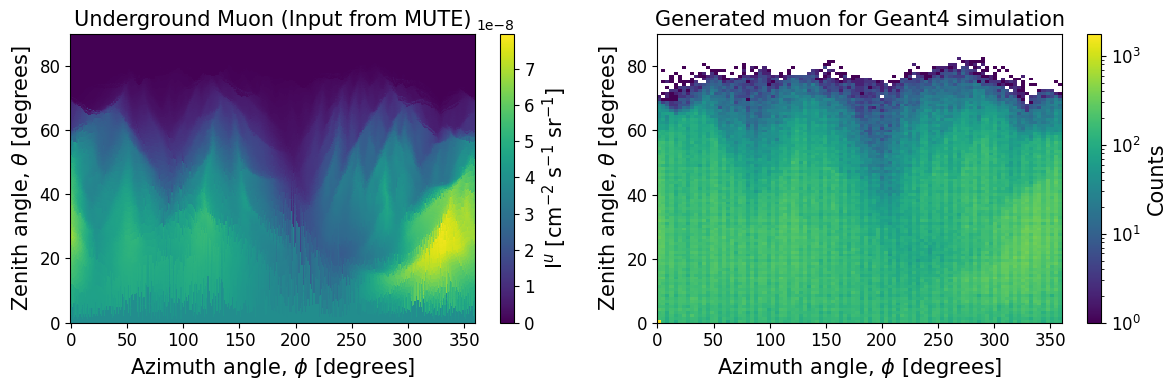

In [17]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
X, Y = np.meshgrid(np.arange(0, 360, 1), np.arange(0, 90, 0.1))
cbar1 = plt.colorbar(ax[0].pcolormesh(X, Y, yemi_intensity['intensity'].values.reshape(900, 360), shading='auto', cmap='viridis'))
cbar1.set_label(r'I$^{u}$ [cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)
cbar1.ax.tick_params(labelsize=12)
ax[0].set_xlabel(r'Azimuth angle, $\phi$ [degrees]', fontsize=15)
ax[0].set_ylabel(r'Zenith angle, $\theta$ [degrees]', fontsize=15)
ax[0].tick_params(axis='both', which='major', labelsize=12) 
ax[0].set_title('Underground Muon (Input from MUTE)', fontsize=15)


# ax.hist2d(phi, theta, bins=100, range=[[0, 360], [0, 90]], norm=LogNorm())
ax[1].hist2d(gen_phi, gen_theta, bins=100, range=[[0, 360], [0, 90]], norm=LogNorm())
cbar2 = plt.colorbar(ax[1].collections[0])
cbar2.set_label('Counts', fontsize=15)
cbar2.ax.tick_params(labelsize=12)
ax[1].set_xlabel(r'Azimuth angle, $\phi$ [degrees]', fontsize=15)
ax[1].set_ylabel(r'Zenith angle, $\theta$ [degrees]', fontsize=15)
ax[1].tick_params(axis='both', which='major', labelsize=12) 
ax[1].set_title('Generated muon for Geant4 simulation', fontsize=15)
plt.tight_layout()
plt.show()


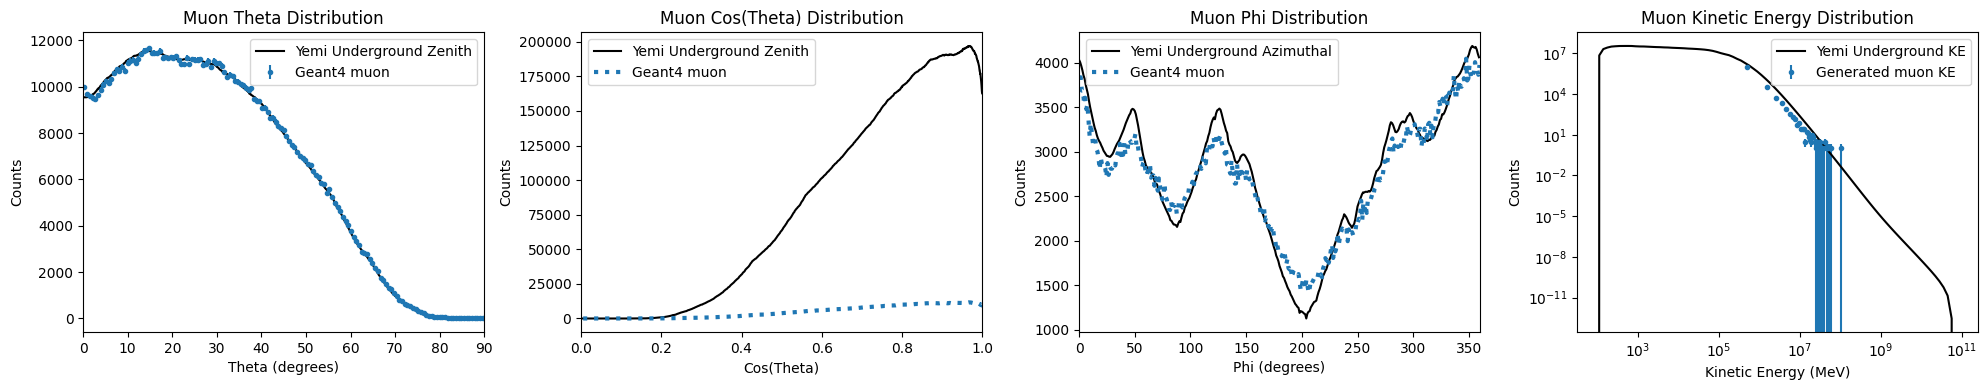

Mean generated muon KE: 259712.75


In [29]:

# Histogram
theta_bins = np.linspace(0,90,150)
phi_bins = np.linspace(0, 360, 360)

hgen_theta, gen_theta_edges = np.histogram(gen_theta, bins=theta_bins)
hgen_phi, gen_phi_edges = np.histogram(gen_phi, bins=phi_bins)
hgen_ke, gen_ke_edges = np.histogram(gen_ke, bins=100)

htheta, theta_edges = np.histogram(theta, bins=theta_bins)
hphi, phi_edges = np.histogram(phi, bins=phi_bins)



fig, ax = plt.subplots(1,4, figsize=(20,4))
ax[0].plot(yemi_theta, yemi_theta_count/yemi_theta_count[:-200].sum()*np.sum(htheta)*(900/150), label='Yemi Underground Zenith', color='k')
# ax[0].plot((gen_theta_edges[:-1] + gen_theta_edges[1:]) / 2, hgen_theta, ':', label='Generated muon', linewidth=3)
# ax[0].plot((theta_edges[:-1] + theta_edges[1:]) / 2, htheta, ':', label='Geant4 muon', linewidth=3)
ax[0].errorbar((theta_edges[:-1] + theta_edges[1:]) / 2, htheta, yerr=np.sqrt(htheta), fmt='.', label='Geant4 muon')
# ax[0].errorbar((gen_theta_edges[:-1] + gen_theta_edges[1:]) / 2, hgen_theta, yerr=np.sqrt(hgen_theta), fmt='.', label='Generated muon')
ax[0].set_xlim(0, 90)
ax[0].set_xlabel('Theta (degrees)')
ax[0].set_ylabel('Counts')
ax[0].set_title('Muon Theta Distribution')
# ax[0].set_yscale('log')
ax[0].legend()


ax[1].plot(np.cos(np.radians(yemi_theta)), yemi_theta_count/yemi_theta_count[:-200].sum()*hgen_theta.sum()*100, label='Yemi Underground Zenith', color='k')
# ax[1].plot(np.cos(np.radians((gen_theta_edges[:-1] + gen_theta_edges[1:]) / 2)), hgen_theta, ':', label='Generated muon', linewidth=3)
ax[1].plot(np.cos(np.radians((theta_edges[:-1] + theta_edges[1:]) / 2)), htheta, ':', label='Geant4 muon', linewidth=3)
# ax[1].errorbar(np.cos(np.radians((gen_theta_edges[:-1] + gen_theta_edges[1:]) / 2)), hgen_theta, yerr=np.sqrt(hgen_theta), fmt='.', label='Generated muon')  
ax[1].set_xlim(0, 1)
ax[1].set_xlabel('Cos(Theta)')
ax[1].set_ylabel('Counts')
ax[1].set_title('Muon Cos(Theta) Distribution')
# ax[1].set_yscale('log')
ax[1].legend()

ax[2].plot(yemi_phi, yemi_phi_count/yemi_phi_count.sum()*hgen_phi.sum(), color='k', label='Yemi Underground Azimuthal')
# ax[2].plot((gen_phi_edges[:-1] + gen_phi_edges[1:]) / 2, hgen_phi, '-', label='Generated muon', linewidth=3)
# ax[2].errorbar((gen_phi_edges[:-1] + gen_phi_edges[1:]) / 2, hgen_phi, yerr=np.sqrt(hgen_phi), fmt='.', label='Generated muon')  
ax[2].plot((phi_edges[:-1] + phi_edges[1:]) / 2, hphi, ':', label='Geant4 muon', linewidth=3)
ax[2].set_xlim(0, 360)
ax[2].set_xlabel('Phi (degrees)')
ax[2].set_ylabel('Counts')
ax[2].set_title('Muon Phi Distribution')
ax[2].legend()


ax[3].errorbar((gen_ke_edges[:-1] + gen_ke_edges[1:]) / 2, hgen_ke, yerr=np.sqrt(hgen_ke), fmt='.', label='Generated muon KE')
ax[3].plot(yemi_ke, yemi_ke_count/yemi_ke_count[40:-20].sum()*hgen_ke.sum(), color='k', label='Yemi Underground KE')
ax[3].set_xlabel('Kinetic Energy (MeV)')
ax[3].set_ylabel('Counts')
ax[3].set_title('Muon Kinetic Energy Distribution')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].legend()
plt.tight_layout()
plt.show()

print("Mean generated muon KE:", gen_ke.mean())



In [22]:
print(len(yemi_ke))
print(htheta)

91
[1.87e+03, 1.66e+03, 1.62e+03, 1.56e+03, 1.61e+03, 1.52e+03, ..., 1, 3, 3, 3, 3]
